Relatório de Classificação:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Matriz de Confusão:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


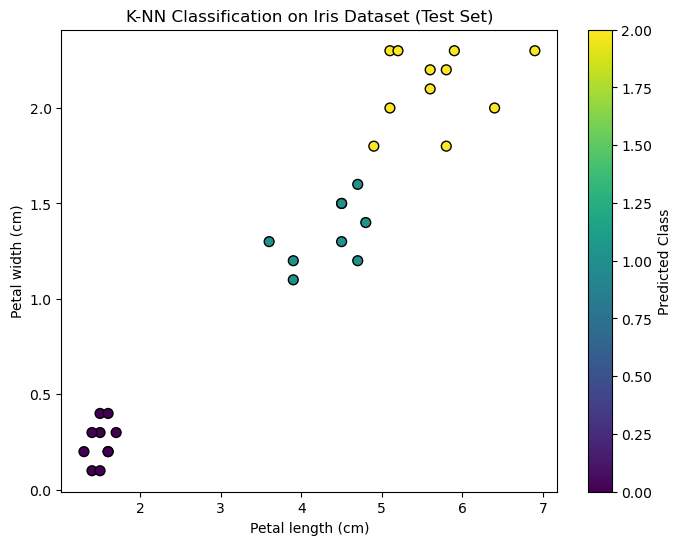

In [ ]:
from pathlib import Path

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt


def resolve_data_path(filename: str, must_exist: bool = True) -> Path:
    candidates = [
        Path.cwd() / "data" / filename,
        Path.cwd().parent / "data" / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()

    if must_exist:
        raise FileNotFoundError(
            f"Nao foi possivel localizar o arquivo de dados '{filename}' em {candidates}."
        )

    for candidate in candidates:
        if candidate.parent.exists():
            return candidate.resolve()

    return candidates[0].resolve()


# Carregar os dados do arquivo CSV
iris_data = pd.read_csv(resolve_data_path("9.0 - iris_dataset.csv"))

# Separar as variaveis independentes e a variavel dependente
X = iris_data.iloc[:, :-1].values
y = iris_data['target'].values

# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Criar e treinar o modelo K-NN
modelo_knn = KNeighborsClassifier(n_neighbors=3)
modelo_knn.fit(X_train, y_train)

# Realizar previsoes com o modelo
y_pred = modelo_knn.predict(X_test)

# Avaliar o modelo
print("Relatorio de Classificacao:\n", classification_report(y_test, y_pred))
print("Matriz de Confusao:\n", confusion_matrix(y_test, y_pred))

# Visualizacao dos resultados
# Escolhendo duas caracteristicas para visualizacao (por exemplo, comprimento e largura da petala)
plt.figure(figsize=(8, 6))
plt.scatter(X_test[:, 2], X_test[:, 3], c=y_pred, cmap='viridis', edgecolor='k', s=50)
plt.xlabel('Petal length (cm)')
plt.ylabel('Petal width (cm)')
plt.title('K-NN Classification on Iris Dataset (Test Set)')
plt.colorbar(label='Predicted Class')
plt.show()